# Running a Hydrometeorological Ensemble Verification Pipeline with _veriflow_

Forecast verification helps us evaluate the quality and behaviour of forecasts. This can include comparing forecasts with observations, assessing skill across lead times, examining forecast uncertainty, or checking whether forecast distributions are realistic under different hydrological conditions.

_veriflow_ is a Python-based framework for running forecast verification workflows in a consistent and reproducible way. It uses a configuration-driven approach to load data, define verification experiments, compute verification metrics and diagnostic statistics, and return results. It can be used to verify both deterministic and probabilistic ensemble forecasts.

## 1. What this notebook does

This notebook focuses on the **workflow**, with an initial visualization of data and verification results:

1. Define a verification configuration
2. Run the _veriflow_ pipeline
3. Inspect the returned results
4. Explore the available data and diagnostics
5. Visualize the results with the interactive app

Note I: The aim of this notebook is to demonstrate usage of _veriflow_, not to provide a complete overview of forecast verification theory.

Note II: A second notebook focuses on the **interpretation** of the verification results, forecast quality and differences between post-processing approaches

---

## 2. Dataset and case study

This example uses hydrometeorological data for the River Rhine basin. We focus on **discharge (`Q`)** and compare three streamflow forecast datasets generated using different meteorological post-processing approaches. Each dataset consists of a 5-member ensemble reforecast. The streamflow forecasts were produced by forcing the HBV hydrological model with raw or post-processed ECMWF ensemble reforecasts of precipitation and temperature.

The forecast datasets are:
- **`raw_raw`**: baseline streamflow forecast driven by raw meteorological ensemble forecasts
- **`lin_log`**: streamflow forecast driven by meteorological ensembles post-processed using a linear-log transformation
- **`qqt_qqt`**: streamflow forecast driven by meteorological ensembles post-processed using a quantile-to-quantile transformation

In this notebook, all forecast datasets are evaluated against the same observation dataset. We focus on running the verification workflow and exploring the resulting output for a key location (**Lobith**).

The data are read directly from a remote Zarr store, so no local download is required. For more information, see the References section.

## 3. Before you start

Before running the pipeline, consider the following questions:

1. What are the three forecast datasets being compared?
2. Why do ensemble forecasts require probabilistic verification methods?
3. What do you expect to happen to forecast skill as lead time increases?

<details>
<summary>Show suggested answers</summary>

1. The forecast variants are `raw_raw`, `lin_log`, and `qqt_qqt`.
2. Ensemble forecasts contain multiple possible realizations of the future, so verification should assess both forecast accuracy and uncertainty representation.
3. Forecast skill is generally expected to decrease as lead time increases, because uncertainty grows further into the future.

</details>

## 4. Imports and environment setup

We start by importing the required Python libraries and _veriflow_ components.

The imports include:

- Required Python tools 
- _veriflow_ components, including configuration objects, Zarr datasource for reading the example data remotely, and pipeline runner
- A local app for interactive visualization


In [28]:
# Add automatic reloading of modules in case of changes
%load_ext autoreload
%autoreload 2

from datetime import datetime, timezone
import logging
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from veriflow.configuration import Config, GeneralInfoConfig
from veriflow.configuration.utils import (
    LeadTimes,
    Range,
    TimeUnits,
    VerificationPair,
    VerificationPeriod,
)
from veriflow.constants import DataType
from veriflow.datasources import ZarrConfig
from veriflow.pipeline import run_pipeline
from veriflow.scores import CrpsForEnsembleConfig, RankHistogramConfig

from app import create_app

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---

## 5. Defining the verification configuration

_veriflow_ is a configuration-driven workflow. The configuration tells the pipeline:

- which data sources to read
- which forecasts and observations to compare
- which lead times to evaluate
- which verification metrics and diagnostic statistics to compute

We define these parts below and then run the full workflow with a single pipeline call.

### 5.1. General verification settings

The general settings define the structure of the verification experiment:

- the verification period
- the forecast lead times
- the verification pairs

Each verification pair represents a single comparison between a forecast dataset and the observations.

In [3]:
general = GeneralInfoConfig(
    # Evaluate forecasts issued during this period.
    verification_period=VerificationPeriod(
        start=datetime(1988, 1, 1, tzinfo=timezone.utc),
        end=datetime(2008, 12, 31, tzinfo=timezone.utc),
        dimension="forecast_reference_time",
    ),
    # Define which forecast datasets are compared against observations.
    verification_pairs=[
        VerificationPair(id="raw_raw", obs="obs", sim="raw_raw", variable="Q"),
        VerificationPair(id="lin_log", obs="obs", sim="lin_log", variable="Q"),
        VerificationPair(id="qqt_qqt", obs="obs", sim="qqt_qqt", variable="Q"),
    ],
    # Evaluate lead times from 0 to 10 days.
    lead_times=LeadTimes(
        unit=TimeUnits.day,
        values=Range(start=0, end=10, step=1),
    ),
)


### 5.2. Data sources

The example data is stored in remote Zarr datasets. Zarr is well suited for cloud-based, multidimensional data access.

Here we define one observation source and three forecast sources. The source names must match the names used in the verification pairs above.

In [4]:
datasources = [
    ZarrConfig(
        general=general,
        import_adapter="zarr",
        source="obs",
        data_type=DataType.observed_historical,
        consolidated=True,
        path="https://s3.deltares.nl/deltares-verification-assets/rhine_dataset_verkade_2013/obs_Q.zarr",
    ),
    ZarrConfig(
        general=general,
        import_adapter="zarr",
        source="raw_raw",
        data_type=DataType.simulated_forecast_ensemble,
        consolidated=True,
        path="https://s3.deltares.nl/deltares-verification-assets/rhine_dataset_verkade_2013/case-raw-raw_Q.zarr",
    ),
    ZarrConfig(
        general=general,
        import_adapter="zarr",
        source="lin_log",
        data_type=DataType.simulated_forecast_ensemble,
        consolidated=True,
        path="https://s3.deltares.nl/deltares-verification-assets/rhine_dataset_verkade_2013/case-lin-log_Q.zarr",
    ),
    ZarrConfig(
        general=general,
        import_adapter="zarr",
        source="qqt_qqt",
        data_type=DataType.simulated_forecast_ensemble,
        consolidated=True,
        path="https://s3.deltares.nl/deltares-verification-assets/rhine_dataset_verkade_2013/case-qqt-qqt_Q.zarr",
    ),
]


### 5.3. Verification metrics and diagnostics

In this notebook, we compute two commonly used diagnostics for ensemble forecasts:

**Continuous Ranked Probability Score (CRPS)** measures how well an ensemble forecast matches the observed outcome. 

- A CRPS of **0** indicates a perfect forecast.
- Lower values indicate better probabilistic forecast quality, indicating the ensemble is centred around the observation and does not unnecessarily spread out.
- CRPS increases when the forecast distribution is biased, too wide, or too narrow relative to the observation.

<span style="color: red;">[Jan's commect: accuracy" is a defined forecast quality attribute which is not measured by CRPS -> Mo: Jurian, I have different opinion here, so it might be nice for you to check what you think suits best]</span>.

**Rank Histogram** assesses statistical reliability by showing where observations fall within the ensemble distribution.

- A roughly uniform histogram indicates a well-calibrated ensemble.
- Systematic patterns can reveal biases or issues with ensemble spread.

The interactive app later in this notebook can be used to explore both CRPS and Rank Histogram.

In [7]:
scores = [
    # CRPS
    CrpsForEnsembleConfig(
        score_adapter="crps_for_ensemble",
        general=general,
        reduce_dims=[],
    ),
    # Rank histogram
    RankHistogramConfig(
        score_adapter="rank_histogram",
        general=general,
        reduce_dims=["forecast_reference_time"],
    ),
]

config = Config(
    fileversion="0.1.0",
    general=general,
    datasources=datasources,
    scores=scores,
)


---

## 6. Running the verification pipeline

With the configuration in place, we can run the _veriflow_ pipeline, which combines the following steps into a workflow:

1. Load the input datasets
2. Align forecasts and observations
3. Compute the requested metrics and diagnostics
4. Return everything in a standardized `OutputDataset`

In [8]:
import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)s %(name)s: %(message)s",
    handlers=[logging.StreamHandler()],
)

output_dataset = run_pipeline(config)


2026-06-01 15:06:53,607 INFO veriflow.pipeline: Successfully initialized the configuration. 
	 verification_period_start = 1988-01-01 00:00:00 
	 verification_period_end = 2008-12-31 00:00:00
2026-06-01 15:06:53,613 INFO veriflow.pipeline: Start getting data from Zarr.
2026-06-01 15:06:53,949 INFO veriflow.pipeline: Successfully got data from Zarr.
2026-06-01 15:06:53,950 INFO veriflow.pipeline: Start getting data from Zarr.
2026-06-01 15:06:53,976 INFO veriflow.pipeline: Successfully got data from Zarr.
2026-06-01 15:06:53,979 INFO veriflow.pipeline: Start getting data from Zarr.
2026-06-01 15:06:54,008 INFO veriflow.pipeline: Successfully got data from Zarr.
2026-06-01 15:06:54,010 INFO veriflow.pipeline: Start getting data from Zarr.
2026-06-01 15:06:54,032 INFO veriflow.pipeline: Successfully got data from Zarr.
2026-06-01 15:06:54,042 INFO veriflow.pipeline: Successfully loaded all data from sources.
2026-06-01 15:06:54,772 INFO veriflow.pipeline: Successfully computed CrpsForEnse

---

## 7. Inspecting the `OutputDataset`

The pipeline returns an **`OutputDataset`**, which provides access to the verification results. Results are organized by **verification pair**, where each pair defines a comparison between an observation dataset and a forecast dataset (for example, `raw_raw` versus observations). Each verification pair contains the aligned input data together with the computed verification metrics.

We start by inspecting the output structure and then extract the results for a single verification pair.

In [13]:
type(output_dataset)

veriflow.datamodel.main.OutputDataset

In [14]:
output_dataset.verification_pairs


[VerificationPair(id='raw_raw', obs='obs', sim='raw_raw', variable='Q'),
 VerificationPair(id='lin_log', obs='obs', sim='lin_log', variable='Q'),
 VerificationPair(id='qqt_qqt', obs='obs', sim='qqt_qqt', variable='Q')]

The output contains three verification pairs, corresponding to the three forecast datasets defined in the configuration.

To make it easier to work with the results, we create:
- a dictionary of verification pair definitions
- a dictionary containing the corresponding `xarray.Dataset` for each pair

In [17]:
verification_pairs = {pair.id: pair for pair in output_dataset.verification_pairs}
pair_datasets = {
    pair_id: output_dataset.get(verification_pair=pair)
    for pair_id, pair in verification_pairs.items()
}


We can now select one verification pair and inspect its dataset. The returned object is an `xarray.Dataset` containing:
- the forecast data
- the corresponding observations
- the computed verification diagnostics (e.g. CRPS and rank histogram)
- metadata and coordinates such as station, lead time, and forecast reference time

In [19]:
pair_id = "raw_raw"
ds = pair_datasets[pair_id]
ds

<xarray.Dataset> Size: 144MB
Dimensions:                  (station: 88, forecast_reference_time: 2924,
                              lead_time: 10, realization: 5, rank: 6)
Coordinates:
  * station                  (station) <U11 4kB 'H-RN-0001' ... 'H-RN-WURZ'
    lat                      (station) float64 704B 0.0 0.0 0.0 ... 0.0 0.0 0.0
    lon                      (station) float64 704B 0.0 0.0 0.0 ... 0.0 0.0 0.0
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 23kB 19...
  * lead_time                (lead_time) timedelta64[ns] 80B 1 days ... 10 days
    time                     (forecast_reference_time, lead_time) datetime64[ns] 234kB ...
  * realization              (realization) int64 40B 0 1 2 3 4
  * rank                     (rank) float64 48B 1.0 2.0 3.0 4.0 5.0 6.0
Data variables:
    obs                      (station, forecast_reference_time, lead_time) float64 21MB ...
    raw_raw                  (forecast_reference_time, lead_time, station, realization) float64 103MB ...
    crps_for_ensemble        (forecast_reference_time, lead_time, station) float64 21MB ...
    histogram_rank           (station, lead_time, rank) float64 42kB 1.136e+0...
Attributes:
    data_type:  observed_historical
    units:      m^3/s

### Questions

Before continuing, take a moment to inspect the dataset above and answer the following questions:

1. How many forecast lead times are available?
2. What is the shortest and longest lead time?
3. How many ensemble members (realizations) does each forecast contain?
4. Which dimensions are present in the forecast data?
5. Which dimensions are present in the observation data?
6. Why do the observations contain a `lead_time` dimension even though observations do not have forecast lead times?

<details>
<summary>Show suggested answers</summary>

1. There are **10 forecast lead times**.
2. The lead times range from **1 day to 10 days**.
3. Each forecast contains **5 ensemble members** (`realization = 5`).
4. The forecast data contain dimensions:
   - `forecast_reference_time`
   - `lead_time`
   - `station`
   - `realization`
5. The observation data contain dimensions:
   - `forecast_reference_time`
   - `lead_time`
   - `station`
6. The observations have been aligned to the forecast structure. For each forecast lead time, the corresponding observed value at the forecast valid time is stored. This makes it easier to compare forecasts and observations and compute verification metrics.

Notice that observations do not have a `realization` dimension because there is only one observed value for each location and time.

</details>

---

## 8. Quick check of aligned input data

Before visualizing the verification results, we briefly inspect the aligned observation and ensemble forecast time series. We do this through the same `OutputDataset` that stores the verification results.

Below, we inspect discharge at the **Lobith station (`H-RN-0001`)** to understand the structure and hydrological behaviour of the aligned observations and forecasts.

In [37]:
obs_da = sample_ds["obs"]
sim_da = sample_ds[sample_pair_id]


def get_lead_coord_name(obj):
    """Return the lead-time coordinate/dimension name used by an xarray object."""
    for name in ["lead_time", "forecast_period"]:
        if name in obj.dims or name in obj.coords:
            return name
    raise KeyError("No lead-time coordinate found. Expected 'lead_time' or 'forecast_period'.")


def select_lead_time(da, lead_days):
    """Select a lead time in days, robust to coordinate naming and dtype."""
    lead_name = get_lead_coord_name(da)
    target = np.timedelta64(lead_days, "D")

    try:
        return da.sel({lead_name: target})
    except Exception:
        try:
            return da.sel({lead_name: lead_days})
        except Exception:
            lead_values = da[lead_name].values
            if np.issubdtype(lead_values.dtype, np.timedelta64):
                lead_values_days = lead_values / np.timedelta64(1, "D")
            else:
                lead_values_days = lead_values

            idx = int(np.where(lead_values_days == lead_days)[0][0])
            return da.isel({lead_name: idx})


def use_valid_time_axis(da):
    """Use valid time as the plotting dimension when available."""
    if "forecast_reference_time" in da.dims and "time" in da.coords:
        return da.swap_dims({"forecast_reference_time": "time"})
    return da


def get_forecast_data(pair_id):
    """Return the forecast DataArray for one verification pair."""
    pair = verification_pairs[pair_id]
    pair_ds = pair_datasets[pair_id]

    if pair.sim in pair_ds.data_vars:
        return pair_ds[pair.sim]
    if pair_id in pair_ds.data_vars:
        return pair_ds[pair_id]

    raise KeyError(f"Could not find forecast variable for pair '{pair_id}'.")

In [38]:
# Lobith station. (You can change this to another station ID.)
example_station = str(obs_da.station.values[0])
example_station


'H-RN-0001'

The figure below shows the observed discharge time series at Lobith, using a 1-day lead time to align the observations for plotting.

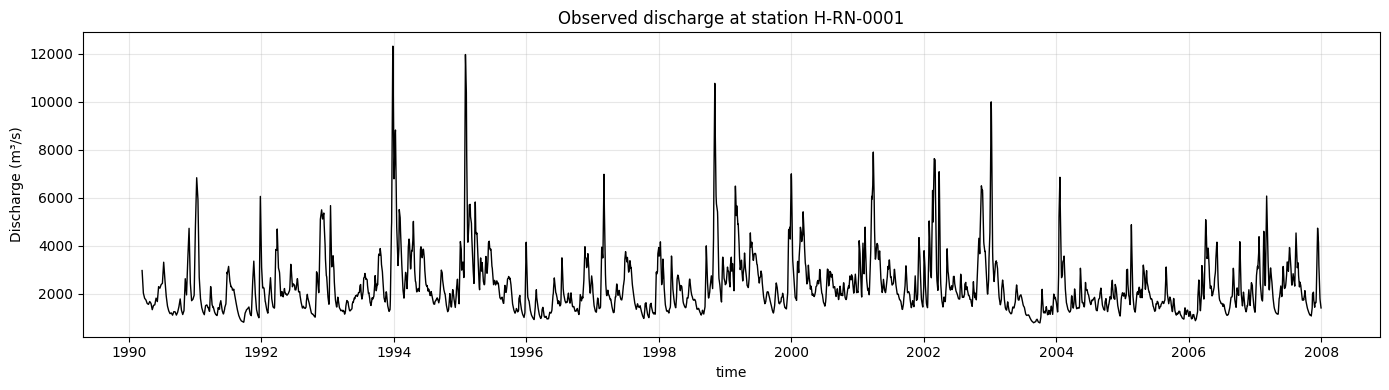

In [34]:
obs_series = select_lead_time(
    obs_da.sel(station=example_station),
    lead_days=1,
)
obs_series = use_valid_time_axis(obs_series)

fig, ax = plt.subplots(figsize=(14, 4))

obs_series.plot(ax=ax, color="black", linewidth=1)
ax.set_title(f"Observed discharge at station {example_station}")
ax.set_ylabel("Discharge (m³/s)")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The next figure shows Lobith discharge observations together with the ensemble mean and spread of each forecast dataset for three lead times: 1, 5, and 10 days. The plot focuses on 1995, when a major flood event took place in the Rhine basin.

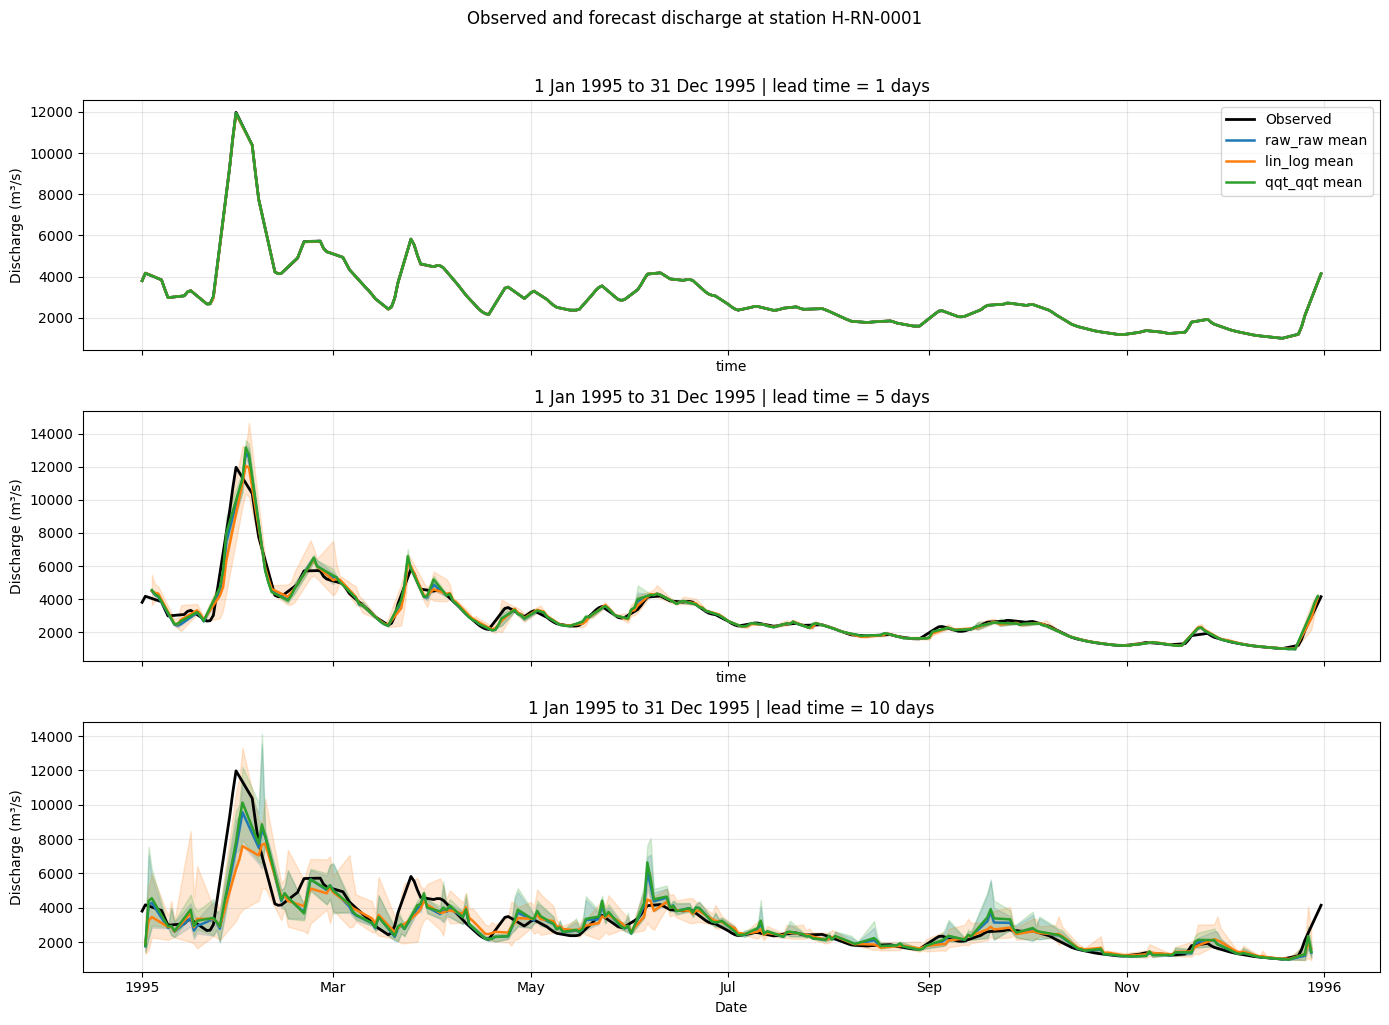

In [35]:
forecast_datasets = {
    pair_id: get_forecast_data(pair_id).sel(station=example_station)
    for pair_id in ["raw_raw", "lin_log", "qqt_qqt"]
}


def forecast_stats_for_lead(da, lead_days):
    """Return ensemble mean, min, and max for a selected lead time."""
    selected = select_lead_time(da, lead_days)

    mean = selected.mean(dim="realization")
    lower = selected.min(dim="realization")
    upper = selected.max(dim="realization")

    return use_valid_time_axis(mean), use_valid_time_axis(lower), use_valid_time_axis(upper)


def plot_event_forecasts(obs_series, forecast_datasets, period, period_label, lead_times=(1, 5, 10)):
    """Plot observed discharge and forecast ensemble summaries for multiple lead times."""
    colors = {
        "raw_raw": "tab:blue",
        "lin_log": "tab:orange",
        "qqt_qqt": "tab:green",
    }

    fig, axes = plt.subplots(len(lead_times), 1, figsize=(14, 10), sharex=True, sharey=False)
    obs_period = obs_series.sel(time=period)

    for ax, lead_days in zip(axes, lead_times):
        obs_period.plot(ax=ax, color="black", linewidth=2, label="Observed")

        for name, da in forecast_datasets.items():
            mean, lower, upper = forecast_stats_for_lead(da, lead_days)
            mean_period = mean.sel(time=period)
            lower_period = lower.sel(time=period)
            upper_period = upper.sel(time=period)

            color = colors[name]
            ax.fill_between(
                mean_period["time"].values,
                lower_period.values,
                upper_period.values,
                color=color,
                alpha=0.18,
            )
            mean_period.plot(ax=ax, color=color, linewidth=1.8, label=f"{name} mean")

        ax.set_title(f"{period_label} | lead time = {lead_days} days")
        ax.set_ylabel("Discharge (m³/s)")
        ax.grid(True, alpha=0.3)

    axes[0].legend(loc="upper right")
    axes[-1].set_xlabel("Date")

    plt.suptitle(f"Observed and forecast discharge at station {example_station}", y=1.02)
    plt.tight_layout()
    plt.show()


Year1995_period = slice("1995-01-01", "1995-12-31")
plot_event_forecasts(
    obs_series=obs_series,
    forecast_datasets=forecast_datasets,
    period=Year1995_period,
    period_label="1 Jan 1995 to 31 Dec 1995",
    lead_times=(1, 5, 10),
)

### Questions

Before opening the interactive app, use the figures above to reflect on what you are about to explore.

1. How does discharge vary through 1995?
2. What does the shaded range around each forecast mean represent?
3. How does forecast behaviour change with lead time?

<details>
<summary>Show suggested answers</summary>

1. Discharge shows seasonal variability, with exceptionally high peaks in February 1995.
2. The shaded range shows the minimum-to-maximum range across ensemble members. A wider range indicates greater ensemble spread and forecast uncertainty.
3. Forecasts generally become less precise at longer lead times. This can appear as larger deviations from observations or wider ensemble spread.

</details>

---

## 9. Interactive visualization of verification results

Now that we have an overview of the observed and ensemble forecast time series and the available verification diagnostics through the **`OutputDataset`**, we can explore the results interactively using a Dash application.

The app makes it possible to:

- compare forecast datasets side by side
- select stations and variables
- inspect results across lead times
- explore forecast behaviour and verification diagnostics

Depending on the app version, views may include scatter plots, CRPS plots, and rank histograms.

### What to look for in the app

When using the app, focus on the following questions:

1. Do forecasts stay close to observations at short lead times?
2. How quickly does forecast quality degrade with lead time?
3. Do the post-processed forecasts behave differently from the raw forecast?
4. Does the ensemble spread appear too narrow, too wide, or approximately reliable?

<details>
<summary>Show suggested direction</summary>

Use the scatter plots to assess agreement between forecasts and observations.  
Use CRPS to compare probabilistic forecast quality across lead times and forecast datasets.  
Use rank histograms to assess whether the ensemble spread is well calibrated.

Detailed interpretation of these results is covered in the second notebook.

</details>

In [36]:
app = create_app(output_dataset)
app.run(jupyter_mode="inline", jupyter_height=1400)


## 10. Next step

You have now run a complete _veriflow_ verification pipeline and explored the output interactively.

The next notebook focuses on **verification interpretation**: how to read scatter plots, CRPS curves, and rank histograms, and how to draw conclusions about forecast performance.

## Optional: YAML-based configuration

This notebook uses Python objects to define the configuration because it is convenient for interactive work.

_veriflow_ can also support YAML-based configuration files, which are useful for reproducible and shareable workflows. A YAML example can be added here once the preferred release configuration format is finalized.


## References

The dataset used in the notebook was originally used in:
> Verkade et al. (2013), *Post-processing ECMWF precipitation and temperature ensemble reforecasts for operational hydrologic forecasting at various spatial scales*, Journal of Hydrology. https://doi.org/10.1016/j.jhydrol.2013.07.039

Additional information is available via 4TU.ResearchData:  
> https://data.4tu.nl/articles/_/12694658/1